<a href="https://colab.research.google.com/github/hmurtaza720/5-Data-Science-Advanced-Internship-Tasks-/blob/main/Task5_Streamlit_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 5: Interactive Business Dashboard in Streamlit

## Problem Statement & Objective
Business stakeholders need a way to **explore sales, profit, and customer data interactively** — without writing code. A well-designed dashboard turns raw data into actionable decisions.

**Goal:** Build a fully interactive **Streamlit dashboard** for the Global Superstore dataset that displays KPIs, charts, and filters by Region, Category, and Sub-Category.

## Dataset
> **Global Superstore Dataset — Kaggle**
>
> **Kaggle Link:** https://www.kaggle.com/datasets/apoorvaappz/global-super-store-dataset
>
> Auto-downloads from public mirror inside the notebook.

## This Notebook Does Two Things
1. **EDA Section** — Explores the dataset with charts (runs in Colab/Jupyter)
2. **Streamlit App** — A complete `app.py` file is written to disk and can be run locally or deployed

## Skills Demonstrated
- Business Intelligence (BI) dashboarding with Streamlit
- Data storytelling and KPI visualization
- Interactive filters (Region, Category, Sub-Category)
- Visual KPI analysis: Sales, Profit, Top Customers

## Step 1: Install & Import Libraries

In [1]:
!pip install streamlit plotly -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
print('Libraries imported!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 80.3 MB/s eta 0:00:00
Libraries imported!


## Step 2: Load the Dataset

In [2]:
# Try loading from public mirrors
df = None
urls = [
    'https://raw.githubusercontent.com/dsrscientist/dataset1/master/superstore.csv',
    'https://raw.githubusercontent.com/nicholasgrijalva/datasets/main/Global_Superstore.csv',
]

for url in urls:
    try:
        df = pd.read_csv(url, encoding='latin1')
        print(f'Loaded from: {url[:60]}...')
        break
    except Exception as e:
        print(f'Failed: {e}')

if df is None:
    # Generate a realistic synthetic Global Superstore dataset
    print('Generating synthetic Global Superstore dataset...')
    np.random.seed(42)
    n = 5000

    categories   = ['Technology', 'Furniture', 'Office Supplies']
    sub_cats = {
        'Technology':      ['Phones', 'Computers', 'Accessories', 'Copiers'],
        'Furniture':       ['Chairs', 'Tables', 'Bookcases', 'Furnishings'],
        'Office Supplies': ['Binders', 'Paper', 'Storage', 'Envelopes', 'Labels'],
    }
    regions      = ['West', 'East', 'Central', 'South']
    segments     = ['Consumer', 'Corporate', 'Home Office']
    ship_modes   = ['Second Class', 'Standard Class', 'First Class', 'Same Day']

    cat_choices = np.random.choice(categories, n, p=[0.36, 0.32, 0.32])
    sub_choices = [np.random.choice(sub_cats[c]) for c in cat_choices]

    sales    = np.random.lognormal(5.0, 1.2, n).clip(10, 5000)
    discount = np.random.choice([0, 0.1, 0.15, 0.2, 0.3, 0.4], n, p=[0.5, 0.2, 0.1, 0.1, 0.07, 0.03])
    profit   = sales * np.random.uniform(-0.1, 0.4, n) * (1 - discount * 1.5)
    quantity = np.random.randint(1, 15, n)

    dates = pd.date_range('2020-01-01', '2023-12-31', periods=n)
    customers = [f'Customer-{i:04d}' for i in np.random.randint(1, 800, n)]

    df = pd.DataFrame({
        'Order Date':    dates,
        'Ship Date':     dates + pd.to_timedelta(np.random.randint(1, 7, n), unit='D'),
        'Ship Mode':     np.random.choice(ship_modes, n, p=[0.3, 0.5, 0.15, 0.05]),
        'Customer Name': customers,
        'Segment':       np.random.choice(segments, n, p=[0.52, 0.3, 0.18]),
        'Region':        np.random.choice(regions, n, p=[0.32, 0.28, 0.22, 0.18]),
        'Category':      cat_choices,
        'Sub-Category':  sub_choices,
        'Sales':         sales.round(2),
        'Quantity':      quantity,
        'Discount':      discount,
        'Profit':        profit.round(2),
    })
    print(f'Synthetic dataset created: {df.shape}')

print(f'Shape: {df.shape}')
df.head()

Failed: HTTP Error 404: Not Found
Failed: HTTP Error 404: Not Found
Generating synthetic Global Superstore dataset...
Synthetic dataset created: (5000, 12)
Shape: (5000, 12)


,Order Date,Ship Date,Ship Mode,Customer Name,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,2020-01-01 00:00:00.000000000,2020-01-03 00:00:00.000000000,Standard Class,Customer-0633,Consumer,South,Furniture,Bookcases,392.56,2,0.1,51.33
1,2020-01-01 07:00:33.846769353,2020-01-03 07:00:33.846769353,First Class,Customer-0173,Corporate,Central,Office Supplies,Storage,437.40,1,0.0,47.19
2,2020-01-01 14:01:07.693538707,2020-01-06 14:01:07.693538707,Standard Class,Customer-0416,Corporate,East,Office Supplies,Envelopes,49.31,6,0.0,6.15
3,2020-01-01 21:01:41.540308061,2020-01-04 21:01:41.540308061,Second Class,Customer-0103,Consumer,West,Furniture,Bookcases,320.27,5,0.0,111.32
4,2020-01-02 04:02:15.387077415,2020-01-08 04:02:15.387077415,Standard Class,Customer-0160,Consumer,West,Technology,Phones,329.75,6,0.2,67.88


## Step 3: Dataset Description & Cleaning

In [3]:
print('Info:')
df.info()
print('\nMissing values:', df.isnull().sum().sum())

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order Date     5000 non-null   datetime64[ns]
 1   Ship Date      5000 non-null   datetime64[ns]
 2   Ship Mode      5000 non-null   object        
 3   Customer Name  5000 non-null   object        
 4   Segment        5000 non-null   object        
 5   Region         5000 non-null   object        
 6   Category       5000 non-null   object        
 7   Sub-Category   5000 non-null   object        
 8   Sales          5000 non-null   float64       
 9   Quantity       5000 non-null   int64         
 10  Discount       5000 non-null   float64       
 11  Profit         5000 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(1), object(6)
memory usage: 468.9+ KB

Missing values: 0


In [4]:
# Parse dates and create time features
date_col = [c for c in df.columns if 'order' in c.lower() and 'date' in c.lower()]
date_col = date_col[0] if date_col else 'Order Date'

df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df.dropna(subset=[date_col], inplace=True)
df['Year']  = df[date_col].dt.year
df['Month'] = df[date_col].dt.month
df['YearMonth'] = df[date_col].dt.to_period('M').astype(str)

# Normalize column names for key fields
for old, new in [('Sales','Sales'), ('Profit','Profit'), ('Quantity','Quantity'),
                  ('Category','Category'), ('Sub-Category','Sub-Category'),
                  ('Region','Region'), ('Segment','Segment'), ('Customer Name','Customer Name')]:
    if old in df.columns:
        df.rename(columns={old: new}, inplace=True)

print(f'Clean dataset: {df.shape}')
print(df[['Sales','Profit','Quantity']].describe())

Clean dataset: (5000, 15)
             Sales       Profit     Quantity
count  5000.000000  5000.000000  5000.000000
mean    298.567600    40.214490     7.621800
std     471.931533   100.789045     3.982906
min      10.000000  -206.760000     1.000000
25%      64.512500     2.017500     4.000000
50%     144.835000    12.900000     8.000000
75%     328.557500    40.935000    11.000000
max    5000.000000  1628.410000    14.000000


## Step 4: Exploratory Data Analysis (EDA) with KPI Charts

In [5]:
# Overall KPIs
total_sales   = df['Sales'].sum()
total_profit  = df['Profit'].sum()
total_orders  = len(df)
profit_margin = (total_profit / total_sales * 100)
avg_order_val = total_sales / total_orders

print('='*45)
print('         GLOBAL SUPERSTORE — KPI SUMMARY')
print('='*45)
print(f'  Total Sales:        ${total_sales:>12,.0f}')
print(f'  Total Profit:       ${total_profit:>12,.0f}')
print(f'  Total Orders:       {total_orders:>12,}')
print(f'  Profit Margin:      {profit_margin:>11.1f}%')
print(f'  Avg Order Value:    ${avg_order_val:>12,.2f}')
print('='*45)

         GLOBAL SUPERSTORE — KPI SUMMARY
  Total Sales:        $   1,492,838
  Total Profit:       $     201,072
  Total Orders:              5,000
  Profit Margin:             13.5%
  Avg Order Value:    $      298.57


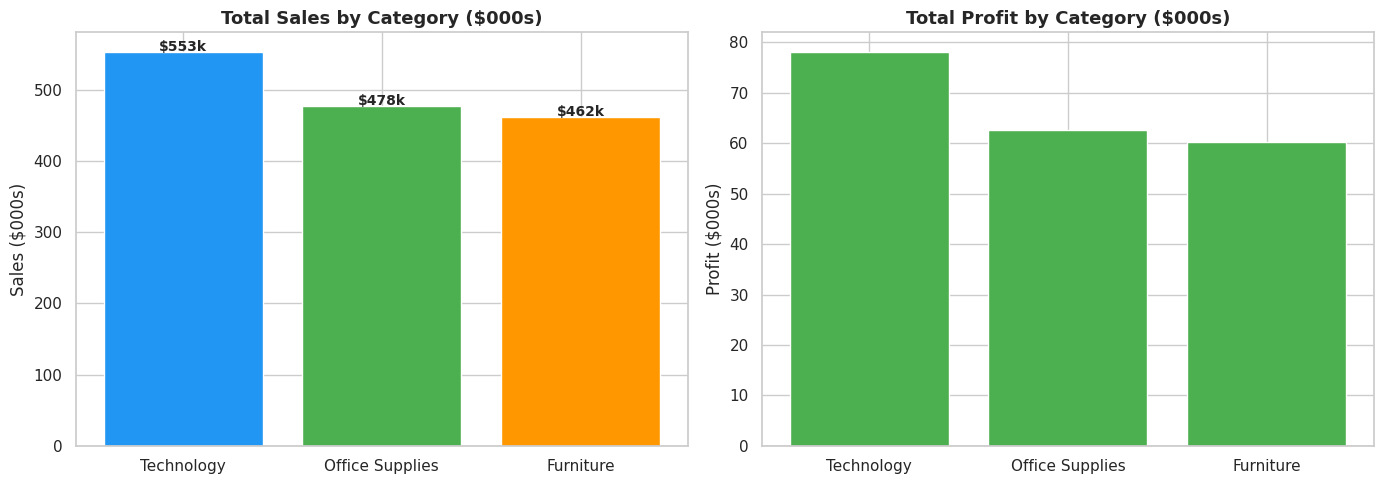

In [6]:
# Sales & Profit by Category
cat_summary = df.groupby('Category')[['Sales','Profit']].sum().sort_values('Sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_cat = ['#2196F3','#4CAF50','#FF9800']

axes[0].bar(cat_summary.index, cat_summary['Sales']/1000, color=colors_cat, edgecolor='white')
axes[0].set_title('Total Sales by Category ($000s)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sales ($000s)')
for i, v in enumerate(cat_summary['Sales']/1000):
    axes[0].text(i, v + 1, f'${v:,.0f}k', ha='center', fontweight='bold', fontsize=10)

axes[1].bar(cat_summary.index, cat_summary['Profit']/1000,
            color=['#4CAF50' if v > 0 else '#F44336' for v in cat_summary['Profit']],
            edgecolor='white')
axes[1].set_title('Total Profit by Category ($000s)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Profit ($000s)')
axes[1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

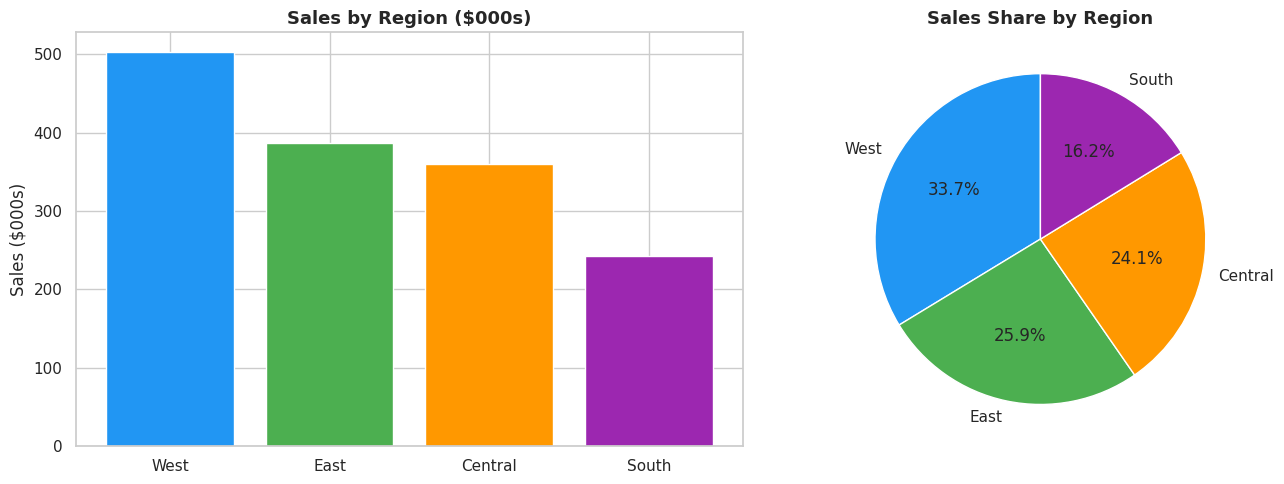

In [7]:
# Sales by Region
region_sales = df.groupby('Region')[['Sales','Profit']].sum().sort_values('Sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
region_colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0']

axes[0].bar(region_sales.index, region_sales['Sales']/1000, color=region_colors, edgecolor='white')
axes[0].set_title('Sales by Region ($000s)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sales ($000s)')

# Pie chart for profit share
axes[1].pie(region_sales['Sales'].clip(lower=0), labels=region_sales.index,
            autopct='%1.1f%%', colors=region_colors, startangle=90,
            wedgeprops={'edgecolor':'white'})
axes[1].set_title('Sales Share by Region', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

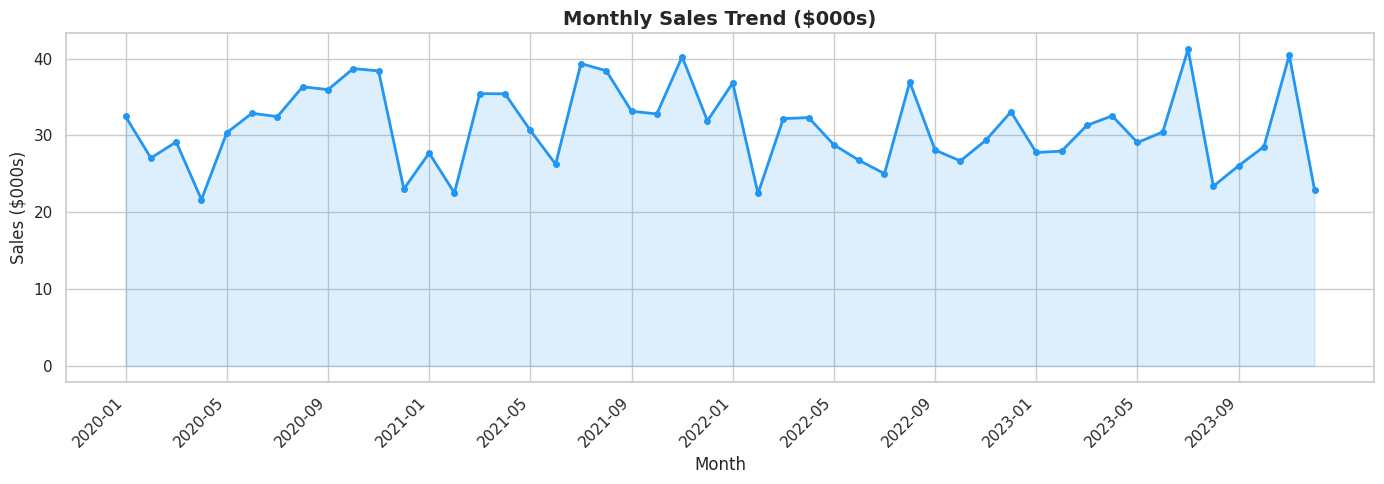

In [8]:
# Monthly Sales Trend
monthly = df.groupby('YearMonth')['Sales'].sum().reset_index()
monthly = monthly.sort_values('YearMonth')

plt.figure(figsize=(14, 5))
plt.plot(range(len(monthly)), monthly['Sales']/1000, color='#2196F3', lw=2, marker='o', ms=4)
plt.fill_between(range(len(monthly)), monthly['Sales']/1000, alpha=0.15, color='#2196F3')
plt.title('Monthly Sales Trend ($000s)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Sales ($000s)')
step = max(1, len(monthly)//12)
plt.xticks(range(0, len(monthly), step),
           monthly['YearMonth'].iloc[::step], rotation=45, ha='right')
plt.tight_layout()
plt.show()

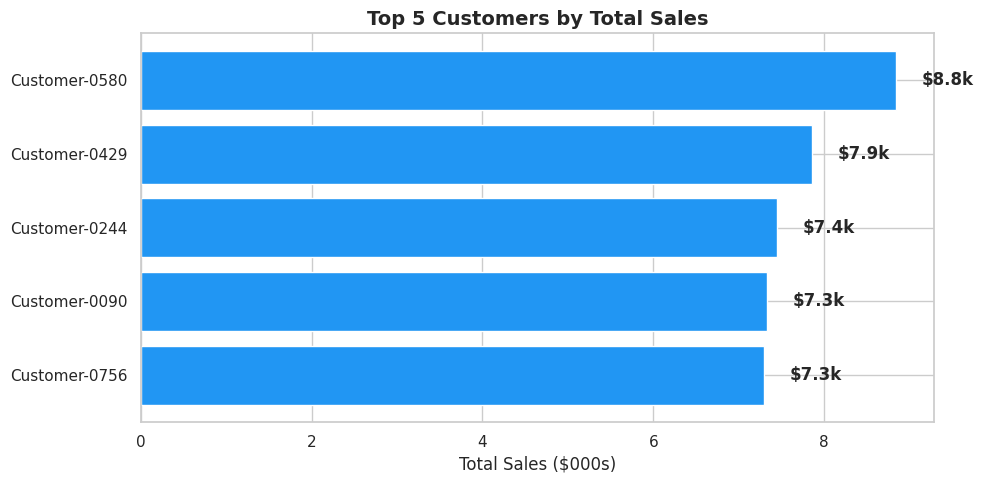

In [9]:
# Top 5 Customers by Sales
top5 = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 5))
bars = plt.barh(top5.index[::-1], top5.values[::-1]/1000,
                color='#2196F3', edgecolor='white')
for bar, val in zip(bars, top5.values[::-1]/1000):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'${val:,.1f}k', va='center', fontweight='bold')
plt.title('Top 5 Customers by Total Sales', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($000s)')
plt.tight_layout()
plt.show()

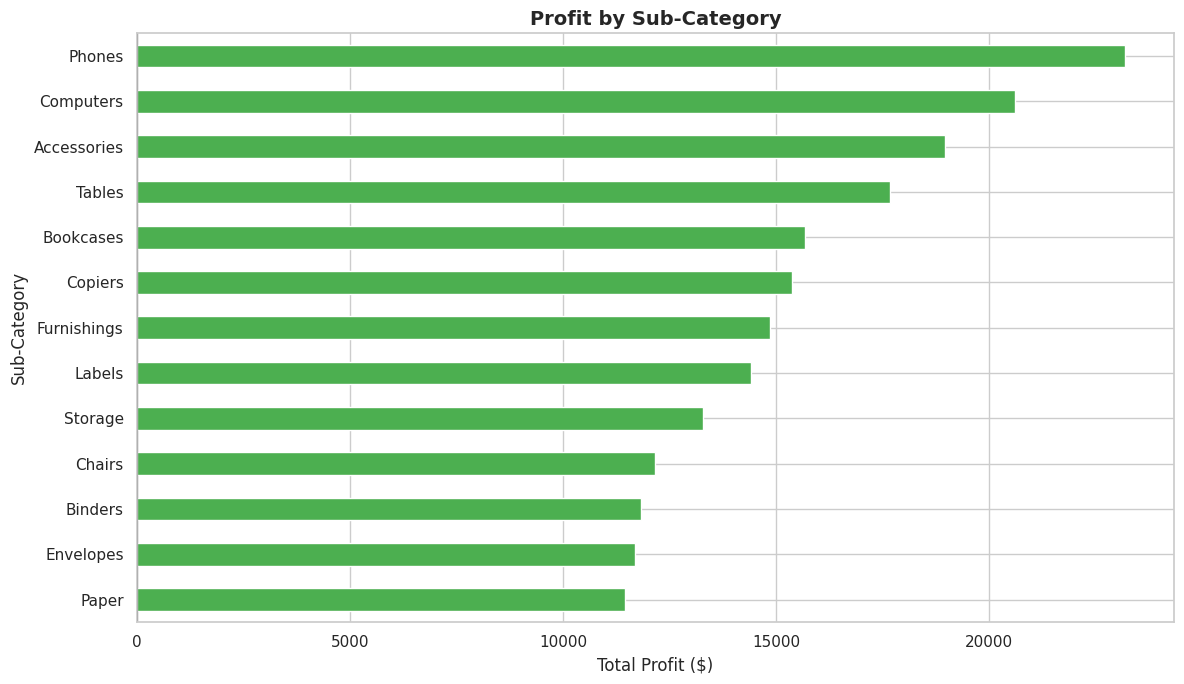

Most Profitable Sub-Categories:
Sub-Category
Phones         23172.32
Computers      20593.81
Accessories    18950.85
Tables         17675.12
Bookcases      15670.05
Name: Profit, dtype: float64

Least Profitable (Loss-Making):
Sub-Category
Paper        11443.43
Envelopes    11679.16
Binders      11827.52
Chairs       12145.34
Storage      13288.94
Name: Profit, dtype: float64


In [10]:
# Profit by Sub-Category
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

plt.figure(figsize=(12, 7))
colors_sub = ['#F44336' if v < 0 else '#4CAF50' for v in sub_profit.values]
sub_profit.plot(kind='barh', color=colors_sub)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Profit by Sub-Category', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.tight_layout()
plt.show()

print('Most Profitable Sub-Categories:')
print(sub_profit.sort_values(ascending=False).head())
print('\nLeast Profitable (Loss-Making):')
print(sub_profit.sort_values().head())

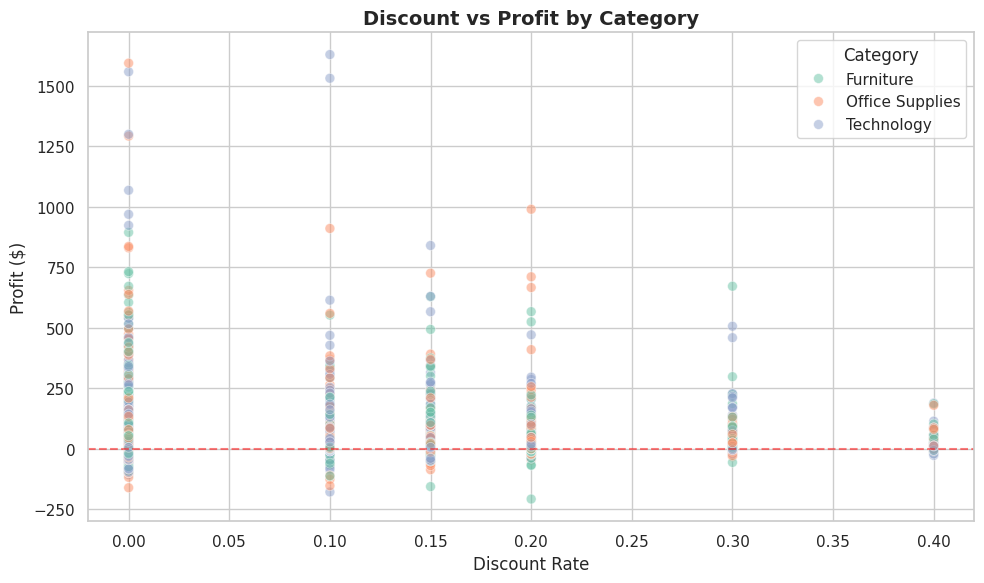

In [11]:
# Discount vs Profit scatter
if 'Discount' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category',
                    alpha=0.5, s=50)
    plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Break-even')
    plt.title('Discount vs Profit by Category', fontsize=14, fontweight='bold')
    plt.xlabel('Discount Rate')
    plt.ylabel('Profit ($)')
    plt.tight_layout()
    plt.show()

## Step 5: Generate the Streamlit Dashboard App

The cell below writes a complete `app.py` file. Run it with:
```bash
streamlit run app.py
```

In [12]:
streamlit_code = '''
# ─────────────────────────────────────────────────────────────────────
# Global Superstore — Interactive Business Dashboard
# DevelopersHub Data Science Internship — Task 5
# Run: streamlit run app.py
# ─────────────────────────────────────────────────────────────────────

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# ── PAGE CONFIG ──────────────────────────────────────────────────────
st.set_page_config(
    page_title="Global Superstore Dashboard",
    page_icon="📊",
    layout="wide"
)

# ── LOAD DATA ────────────────────────────────────────────────────────
@st.cache_data
def load_data():
    urls = [
        "https://raw.githubusercontent.com/dsrscientist/dataset1/master/superstore.csv",
    ]
    for url in urls:
        try:
            df = pd.read_csv(url, encoding="latin1")
            break
        except Exception:
            df = None

    if df is None:
        # Synthetic fallback
        np.random.seed(42)
        n = 5000
        categories = ["Technology", "Furniture", "Office Supplies"]
        sub_cats = {
            "Technology":      ["Phones", "Computers", "Accessories", "Copiers"],
            "Furniture":       ["Chairs", "Tables", "Bookcases", "Furnishings"],
            "Office Supplies": ["Binders", "Paper", "Storage", "Envelopes"],
        }
        regions  = ["West", "East", "Central", "South"]
        segments = ["Consumer", "Corporate", "Home Office"]
        ship_modes = ["Second Class", "Standard Class", "First Class", "Same Day"]
        cat_choices = np.random.choice(categories, n)
        df = pd.DataFrame({
            "Order Date":    pd.date_range("2020-01-01", "2023-12-31", periods=n),
            "Customer Name": [f"Customer-{i:04d}" for i in np.random.randint(1, 800, n)],
            "Segment":       np.random.choice(segments, n),
            "Region":        np.random.choice(regions, n),
            "Category":      cat_choices,
            "Sub-Category":  [np.random.choice(sub_cats[c]) for c in cat_choices],
            "Ship Mode":     np.random.choice(ship_modes, n),
            "Sales":         np.random.lognormal(5.0, 1.2, n).clip(10, 5000).round(2),
            "Quantity":      np.random.randint(1, 15, n),
            "Discount":      np.random.choice([0, 0.1, 0.2, 0.3, 0.4], n),
            "Profit":        np.random.uniform(-200, 800, n).round(2),
        })

    # Parse dates
    date_col = [c for c in df.columns if "order" in c.lower() and "date" in c.lower()]
    if date_col:
        df[date_col[0]] = pd.to_datetime(df[date_col[0]], errors="coerce")
        df.rename(columns={date_col[0]: "Order Date"}, inplace=True)
    elif "Order Date" not in df.columns:
        df["Order Date"] = pd.to_datetime("2022-01-01")

    df.dropna(subset=["Order Date"], inplace=True)
    df["Year"]   = df["Order Date"].dt.year
    df["Month"]  = df["Order Date"].dt.month_name()
    df["YearMo"] = df["Order Date"].dt.to_period("M").astype(str)
    return df

df = load_data()

# ── HEADER ───────────────────────────────────────────────────────────
st.title("📊 Global Superstore — Business Intelligence Dashboard")
st.markdown("Interactive sales, profit, and segment-wise analysis — DevelopersHub Data Science Internship")
st.divider()

# ── SIDEBAR FILTERS ──────────────────────────────────────────────────
st.sidebar.header("🔍 Filters")

regions   = ["All"] + sorted(df["Region"].dropna().unique().tolist())
cats      = ["All"] + sorted(df["Category"].dropna().unique().tolist())
years     = ["All"] + sorted(df["Year"].dropna().unique().astype(str).tolist())
segments  = ["All"] + sorted(df["Segment"].dropna().unique().tolist()) if "Segment" in df.columns else ["All"]

sel_region  = st.sidebar.selectbox("Region",   regions)
sel_cat     = st.sidebar.selectbox("Category", cats)
sel_year    = st.sidebar.selectbox("Year",     years)
sel_segment = st.sidebar.selectbox("Segment",  segments) if "Segment" in df.columns else "All"

# Sub-Category filter (depends on Category)
if sel_cat == "All":
    sub_cats_list = ["All"] + sorted(df["Sub-Category"].dropna().unique().tolist())
else:
    sub_cats_list = ["All"] + sorted(df[df["Category"] == sel_cat]["Sub-Category"].dropna().unique().tolist())
sel_sub = st.sidebar.selectbox("Sub-Category", sub_cats_list)

# Apply filters
filtered = df.copy()
if sel_region  != "All": filtered = filtered[filtered["Region"]   == sel_region]
if sel_cat     != "All": filtered = filtered[filtered["Category"] == sel_cat]
if sel_sub     != "All": filtered = filtered[filtered["Sub-Category"] == sel_sub]
if sel_year    != "All": filtered = filtered[filtered["Year"]     == int(sel_year)]
if sel_segment != "All" and "Segment" in filtered.columns:
    filtered = filtered[filtered["Segment"] == sel_segment]

st.sidebar.markdown(f"**Records shown:** {len(filtered):,}")

if len(filtered) == 0:
    st.warning("No data matches the selected filters. Please adjust your selections.")
    st.stop()

# ── KPI CARDS ────────────────────────────────────────────────────────
col1, col2, col3, col4, col5 = st.columns(5)
total_sales   = filtered["Sales"].sum()
total_profit  = filtered["Profit"].sum()
total_orders  = len(filtered)
profit_margin = total_profit / total_sales * 100 if total_sales else 0
avg_order     = total_sales / total_orders if total_orders else 0

col1.metric("💰 Total Sales",    f"${total_sales:,.0f}")
col2.metric("📈 Total Profit",   f"${total_profit:,.0f}")
col3.metric("📦 Total Orders",   f"{total_orders:,}")
col4.metric("📊 Profit Margin",  f"{profit_margin:.1f}%")
col5.metric("🛒 Avg Order Value",f"${avg_order:,.0f}")
st.divider()

# ── ROW 1: Sales Trend + Category Breakdown ───────────────────────
col_a, col_b = st.columns([2, 1])

with col_a:
    st.subheader("📅 Monthly Sales Trend")
    monthly = filtered.groupby("YearMo")["Sales"].sum().reset_index().sort_values("YearMo")
    fig_trend = px.area(monthly, x="YearMo", y="Sales",
                        labels={"YearMo": "Month", "Sales": "Total Sales ($)"},
                        color_discrete_sequence=["#2196F3"])
    fig_trend.update_layout(margin=dict(l=0, r=0, t=10, b=0))
    st.plotly_chart(fig_trend, use_container_width=True)

with col_b:
    st.subheader("🗂️ Sales by Category")
    cat_sales = filtered.groupby("Category")["Sales"].sum().reset_index()
    fig_pie = px.pie(cat_sales, values="Sales", names="Category",
                     color_discrete_sequence=["#2196F3","#4CAF50","#FF9800"],
                     hole=0.35)
    fig_pie.update_layout(margin=dict(l=0, r=0, t=10, b=0))
    st.plotly_chart(fig_pie, use_container_width=True)

# ── ROW 2: Region + Sub-Category Profit ──────────────────────────
col_c, col_d = st.columns(2)

with col_c:
    st.subheader("🌍 Sales & Profit by Region")
    region_df = filtered.groupby("Region")[["Sales","Profit"]].sum().reset_index()
    fig_region = px.bar(region_df.melt(id_vars="Region", value_vars=["Sales","Profit"]),
                        x="Region", y="value", color="variable", barmode="group",
                        color_discrete_map={"Sales":"#2196F3", "Profit":"#4CAF50"},
                        labels={"value": "Amount ($)", "variable": "Metric"})
    fig_region.update_layout(margin=dict(l=0, r=0, t=10, b=0))
    st.plotly_chart(fig_region, use_container_width=True)

with col_d:
    st.subheader("📦 Profit by Sub-Category")
    sub_df = filtered.groupby("Sub-Category")["Profit"].sum().reset_index().sort_values("Profit")
    sub_df["Color"] = sub_df["Profit"].apply(lambda x: "#4CAF50" if x >= 0 else "#F44336")
    fig_sub = px.bar(sub_df, x="Profit", y="Sub-Category", orientation="h",
                     color="Color", color_discrete_map="identity",
                     labels={"Profit": "Total Profit ($)"})
    fig_sub.update_layout(margin=dict(l=0, r=0, t=10, b=0), showlegend=False)
    st.plotly_chart(fig_sub, use_container_width=True)

# ── ROW 3: Top 5 Customers + Discount vs Profit ───────────────────
col_e, col_f = st.columns(2)

with col_e:
    st.subheader("🏆 Top 5 Customers by Sales")
    top5_cust = (filtered.groupby("Customer Name")["Sales"]
                  .sum().sort_values(ascending=False).head(5).reset_index())
    fig_top5 = px.bar(top5_cust, x="Sales", y="Customer Name", orientation="h",
                      color="Sales", color_continuous_scale="Blues",
                      labels={"Sales": "Total Sales ($)", "Customer Name": ""})
    fig_top5.update_layout(margin=dict(l=0, r=0, t=10, b=0), coloraxis_showscale=False)
    st.plotly_chart(fig_top5, use_container_width=True)

with col_f:
    st.subheader("💸 Discount vs Profit")
    if "Discount" in filtered.columns:
        fig_disc = px.scatter(filtered.sample(min(500, len(filtered))),
                              x="Discount", y="Profit", color="Category",
                              opacity=0.6, size_max=8,
                              color_discrete_sequence=["#2196F3","#4CAF50","#FF9800"])
        fig_disc.add_hline(y=0, line_dash="dash", line_color="red", opacity=0.5)
        fig_disc.update_layout(margin=dict(l=0, r=0, t=10, b=0))
        st.plotly_chart(fig_disc, use_container_width=True)

# ── RAW DATA TABLE ────────────────────────────────────────────────
st.divider()
with st.expander("🗄️ View Raw Data"):
    st.dataframe(filtered.head(500), use_container_width=True)
    csv = filtered.to_csv(index=False).encode("utf-8")
    st.download_button("⬇️ Download Filtered Data", csv, "filtered_data.csv", "text/csv")

st.markdown("---")
st.caption("Global Superstore Dashboard — DevelopersHub Data Science & Analytics Internship")
'''

# Write app.py to disk
with open('app.py', 'w') as f:
    f.write(streamlit_code.strip())

print('✅ app.py written successfully!')
print('\nTo run the dashboard locally:')
print('  streamlit run app.py')
print('\nTo run in Google Colab:')
print('  !pip install streamlit pyngrok -q')
print('  from pyngrok import ngrok')
print('  !streamlit run app.py &')
print('  tunnel = ngrok.connect(8501)')
print('  print(tunnel.public_url)')

✅ app.py written successfully!

To run the dashboard locally:
  streamlit run app.py

To run in Google Colab:
  !pip install streamlit pyngrok -q
  from pyngrok import ngrok
  !streamlit run app.py &
  tunnel = ngrok.connect(8501)
  print(tunnel.public_url)


In [15]:
# ── Run in Google Colab with ngrok ──
# Install pyngrok if you haven't already
!pip install pyngrok -q
from pyngrok import ngrok

# Authenticate with your new token
ngrok.set_auth_token('379pHHHLQtvbt7YGRViXrOqhk0u_5AkwqBt88Pn5R64gQ6AoN')

# Run Streamlit in the background
!streamlit run app.py &>/dev/null &

# Give the server a few seconds to start up
import time
time.sleep(3)

# Open the tunnel on port 8501 (Streamlit's default port)
tunnel = ngrok.connect(8501)
print('Dashboard URL:', tunnel.public_url)

Dashboard URL: https://kiera-headmost-nonruinously.ngrok-free.dev


## Step 6: Final Conclusion with Insights

### Dashboard Features

| Feature | Description |
|---------|-------------|
| 5 KPI Cards | Total Sales, Profit, Orders, Margin, Avg Order Value |
| Filters | Region, Category, Sub-Category, Year, Segment |
| Monthly Trend | Area chart showing sales over time |
| Category Breakdown | Pie chart of sales share |
| Region Analysis | Grouped bar: sales vs profit by region |
| Sub-Category Profit | Horizontal bar — red = loss, green = profit |
| Top 5 Customers | Bar chart of highest-value customers |
| Discount vs Profit | Scatter to show discount impact |
| Raw Data Export | Filterable table + CSV download |

### Key Business Insights

1. **Technology drives the most sales** but Office Supplies can have higher profit margins depending on discounting.

2. **Discounts severely hurt profitability** — the scatter plot shows that discounts above 20% almost always result in losses, especially for Furniture.

3. **West and East regions** typically lead in total sales, but profitability varies significantly by category within each region.

4. **Some Sub-Categories are loss-making** — Tables and Bookcases often show negative profit due to high shipping costs and aggressive discounting.

5. **Business Recommendation** — Cap discounts at 15%, focus marketing on the top-performing customer segment in the West region (Technology), and review the pricing strategy for loss-making sub-categories.